# #5 Medical text classification with attention / Transformer

In this notebook, we are training a a complex model: our first transformer-like architecture with the goal of classififying reports from their speciality origin.

You'll see that it's not perfect, but we are using a really simple model. The idea is to show that transformers are also not that hard to code! And to show some interesting data preprocessing

In [1]:
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score



import seaborn as sns

Fixing the seeds for replicability

In [2]:
seed = 50

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

Our data come from a Kaggle challenge with medical reports text and their class being the medical speciality. We re going to predict one from the other
https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions?resource=download

In [3]:
path = '../data'

In [4]:
# ## If you are in google collab, uncomment this cell and run it:
# ## It will ask you to uplad a file, upload mtsamples.csv from the local data folder

# from google.colab import files
# uploaded = files.upload()
# path = '.'


# Prepare the data
The data preparation is a bit complex. We need to:
- extract the data
- select the most common classes (easier training)
- Transform labels in token (one hot encoding)
- clean the text from numbers, ponctuations etc
- Keep only the most common words (smaller vocabulary)
- Transform each word to an integer
- Fix the trasncript to the same size (padding and cutting)

### 1. Extract and inspect the data

Text(0, 0.5, 'counts')

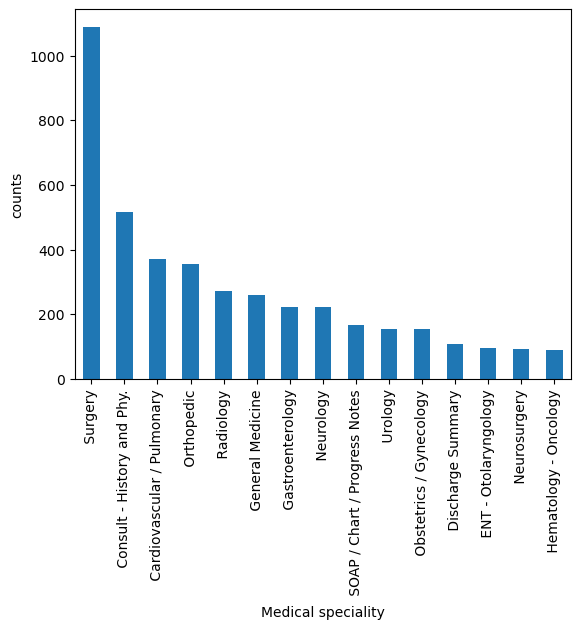

In [5]:
df = pd.read_csv("../data/mtsamples.csv")
df = df[["medical_specialty", "transcription"]].dropna()
df["medical_specialty"].value_counts().head(15).plot.bar()
plt.xlabel('Medical speciality')
plt.ylabel('counts')

### 2. Only select the reports of the 9 most common specialities

In [6]:
n_classes = 9
counts = df.medical_specialty.value_counts()
keep_classes = counts.index[:n_classes]
df = df[df.medical_specialty.isin(keep_classes)]

In [7]:
df.medical_specialty.value_counts()

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Name: count, dtype: int64

### 3. Transform the labels (medical speciality) in numbers

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["medical_specialty"]
)

for i, class_name in enumerate(encoder.classes_):
    print(f"{i} -> {class_name}")


0 ->  Cardiovascular / Pulmonary
1 ->  Consult - History and Phy.
2 ->  Gastroenterology
3 ->  General Medicine
4 ->  Neurology
5 ->  Orthopedic
6 ->  Radiology
7 ->  SOAP / Chart / Progress Notes
8 ->  Surgery


4. Clean the texts

In [9]:
import re

def clean_text(text):

    text = text.lower()  # remove capitals

    text = re.sub(r"[^a-z ]", " ", text)  # remove anything that is nor space nor letter

    text = re.sub(r"\s+", " ", text)  # collapse multiple spaces in one

    return text.strip()

texts = df["transcription"].values

clean_texts = [
    clean_text(t)
    for t in texts
]

In [10]:
print('Text example before cleaning: \n', texts[0])
print('Text example after cleaning: \n', clean_texts[0])

Text example before cleaning: 
 2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic valve, mitral valve, tricuspid valve, and pulmonary valve.,7.  PA systolic pressure is 36 mmHg.,DOPPLER: , ,1.  Mild mitral and tricuspid regurgitation.,2.  Trace aortic and pulmonary regurgitation.
Text example after cleaning: 
 d m mode left atrial enlargement with left atrial diameter of cm normal size right and left ventricle normal lv systolic function with left ventricular ejection fraction of normal lv diastolic function no pericardial effusion normal morphology of aortic valve mitral valve tricuspid valve and pulmonary valve pa systolic pressure is mmhg doppler mild mitral and tricuspid regurgitation trace aortic and pulmonary regurgitation


### 4. Keep only the 3000 more represented words

In [11]:
vocab_size = 3000
counter = Counter()

for text in clean_texts:

    words = text.split()

    counter.update(words)

most_common = counter.most_common(
    vocab_size
)

### 5. trasnform each word to an integer

In [12]:
### special idx for padding (if we have sentences less than our max sentence limit)
# and unknown model
word2idx = {
    "<PAD>":0,
    "<UNK>":1
}
# create the mapping dictionnary between our most used words and the integers
for i, (word, count) in enumerate(most_common):

    word2idx[word] = i + 2
print(f"the index for the word patient is {word2idx["patient"]}")
print(f"the index for the word pneumonia is {word2idx["pneumonia"]}")

the index for the word patient is 11
the index for the word pneumonia is 858


use the created mapping dictionnary to trasnform our input data

In [13]:
def encode_text(text):

    words = text.split()

    tokens = []

    for word in words:

        token = word2idx.get(
            word,
            word2idx["<UNK>"]
        )

        tokens.append(token)

    return tokens


And use padding for smaller sets

In [14]:

MAX_LEN = 128
def pad_sequence(tokens):

    tokens = tokens[:MAX_LEN]

    padding = MAX_LEN - len(tokens)

    tokens = tokens + [0] * padding

    return tokens

In [15]:
x_encoded = []

for text in clean_texts:

    tokens = encode_text(text)

    tokens = pad_sequence(tokens)

    x_encoded.append(tokens)
x_encoded = np.array(x_encoded)

In [16]:
print('encoded shapes: ', np.shape(x_encoded))
print('examples: ', x_encoded[0])

encoded shapes:  (3475, 128)
examples:  [ 233  648    1   22  336 1485    8   22  336 1074    5  101   31  296
   21    3   22  716   31 1214  679  432    8   22  313  905  986    5
   31 1214 1563  432   12 1446  752   31    1    5  338  341  937  341
 1603  341    3  197  341    1  679   92   10  501 1976  131  937    3
 1603 1062 1801  338    3  197 1062    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


### data batching and prep
We use the torch dataset utils to create our dataset more efficiently

In [17]:
class MedicalDataset(
    torch.utils.data.Dataset
):

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x[idx], self.y[idx]
        )

In [18]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x_encoded, y, test_size=0.4, random_state=seed, stratify=y)

x_validation, x_test, y_validation, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)
x_train = torch.LongTensor(x_train)  #integer, not float
y_train = torch.LongTensor(y_train)

x_validation = torch.LongTensor(x_validation)
y_validation = torch.LongTensor(y_validation)

x_test = torch.LongTensor(x_test)
y_test = torch.LongTensor(y_test)

In [19]:
train_dataset = MedicalDataset(x_train, y_train)
validation_dataset = MedicalDataset(x_validation, y_validation)
test_dataset = MedicalDataset(x_test, y_test)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
validation_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=32
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32
)

# Model definition

Our model is going to be a classifier using transformer like embeddings. 
For this we re going to create the Attention bloc, the transformer block using these attention, and finally the global model that uses transfomers and a simple MLP classififer

## Attention

In [20]:
embedding_dim = 64

class SelfAttention(nn.Module):

    def __init__(self, d_model):

        super().__init__()
        
        # Create queries, keys, values using dense layers
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask):

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        # Attention is  Q * K (with the good transpoition for matrix multiplication)
        scores = Q @ K.transpose(-2, -1)
        # We normalise the Attention
        scores = scores / (Q.shape[-1] ** 0.5)
        # we mask the attention that comes from padded values
        scores = scores.masked_fill(mask == 0, -1e9)
        # attention is the softmax of this attention matrix
        attention = torch.softmax(
            scores,
            dim=-1
        )
        # use dropout during training
        attention = self.dropout(attention)

        # New learnt values are the attention * previous values
        new_value = attention @ V
        return new_value

## Transformer block
Transformer block does attention, normalisation, and two successivedense layers in the embeddings

In [21]:
class TransformerBlock(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.attention = SelfAttention(d_model)
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(4*d_model, d_model))

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        
        x = self.norm1(x + self.dropout(self.attention(x, mask)))
        x = self.norm2(x + self.ffn(x))
        return x


## Full model
The model:
-  prepare the token embeddings (input + positional embeddinf that just one hot of the position of each word) and the mask for padding
- Two consecutive transformer blocks
- A classifier in the learn embeddings, with two Linear and dropout

In [22]:

class MedicalTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        n_classes
    ):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.position_embedding = nn.Embedding(MAX_LEN, embedding_dim)
        self.block1 = TransformerBlock(embedding_dim)
        self.block2 = TransformerBlock(embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes))

    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()
        positions = torch.arange(
            x.shape[1],
            device=x.device
        )

        x = (self.embedding(x) + self.position_embedding(positions))
        x = self.block1(x, mask)
        x = self.block2(x, mask)
        x = (x * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)
        x = self.classifier(x)
        return x

In [23]:
model = MedicalTransformer(
    vocab_size=len(word2idx),
    n_classes=n_classes
)

## weighted loss
Our dataset is highly unbalanced. To prevent mode collapse, we are comoputing the relative presence of each of the labels. During the trainig, the loss is going to be weighted with those: if the model does an error in a rare label, it should be penalise much more.

In [24]:
y_train_np = y_train.detach().cpu().numpy().reshape(-1)
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_np),
    y=y_train_np
)
weights = torch.tensor(
    weights,
    dtype=torch.float32
)

### Our loss is the cross entropy between each label

In [25]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

## OUr train function is always the same, nothing changes

In [26]:
def train_model(model, optimizer):
    losses_steps = []
    losses_epochs = []
    validation_losses = []
    for epoch in range(35):
        if epoch % 5 == 0:
            print(f'epoch: {epoch}')
        loss_epoch = 0

        # loop through the dataset per batch
        for x_batch, y_batch in train_loader:
            model.train()
            # use the model to predict on the batch
            pred_y = model(x_batch)

            # Compute the loss on the batch and log it
            loss = criterion(pred_y, y_batch)
            loss_epoch += loss.detach().numpy()
            losses_steps.append(loss.detach().numpy())

            # Zero gradients (not accumulate)
            optimizer.zero_grad()
            
            # compute the gradients
            loss.backward()

            # apply the gradients to optimise
            optimizer.step()
            
        # Compute the mean loss on the epoch
        model.eval()
        pred_val_y = model(x_validation)
        val_loss = criterion(pred_val_y, y_validation)
        validation_losses.append(val_loss.detach().numpy())
        losses_epochs.append(loss_epoch / len(train_loader))
    return losses_epochs, losses_steps, validation_losses


In [27]:
losses_epochs, losses_steps, validation_losses = train_model(model, optimizer)

epoch: 0
epoch: 5
epoch: 10
epoch: 15
epoch: 20
epoch: 25
epoch: 30


## Plot the losses

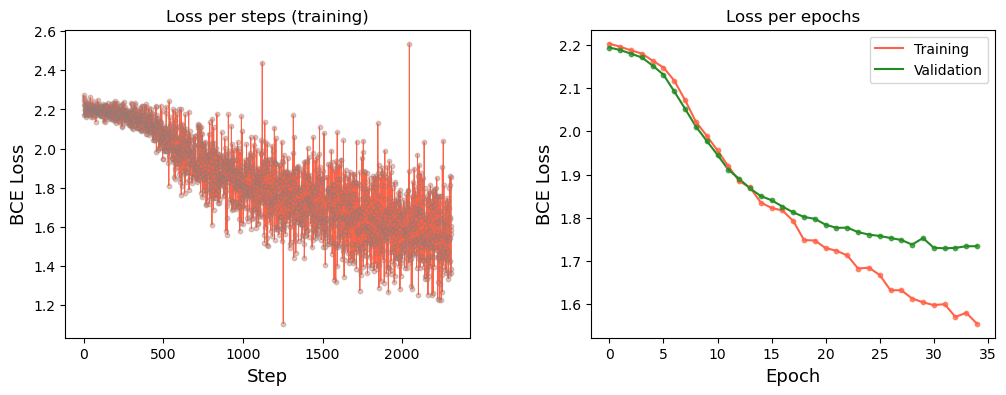

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=0.4, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='tomato', lw=.7)


ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=0.7, s=10, c='tomato', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='tomato', label='Training')
ax[1].scatter(np.arange(len(losses_epochs)), validation_losses, alpha=0.7, s=10, c='forestgreen', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), validation_losses, c='forestgreen', label='Validation')


[axe.set_ylabel('BCE Loss', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps (training)')
ax[1].set_title('Loss per epochs')
ax[1].legend();

Predict on the test set

In [29]:
model.eval()

all_predictions = []
all_truth = []
all_logits = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        logits = model(x_batch)
        # take the argmax to get the most probable label predicted
        pred = torch.argmax(logits, dim=1)

        all_predictions.extend(pred.cpu().numpy())

        all_truth.extend(y_batch.cpu().numpy())

        all_logits.extend(logits.cpu().numpy())

all_predictions = np.array(all_predictions)
all_truth = np.array(all_truth)
all_logits = np.array(all_logits)

## Global accuracy

In [30]:
acc = accuracy_score(
    all_truth,
    all_predictions
)

print(f"Accuracy = {acc:.3f}")

Accuracy = 0.424


## Confusion matrix

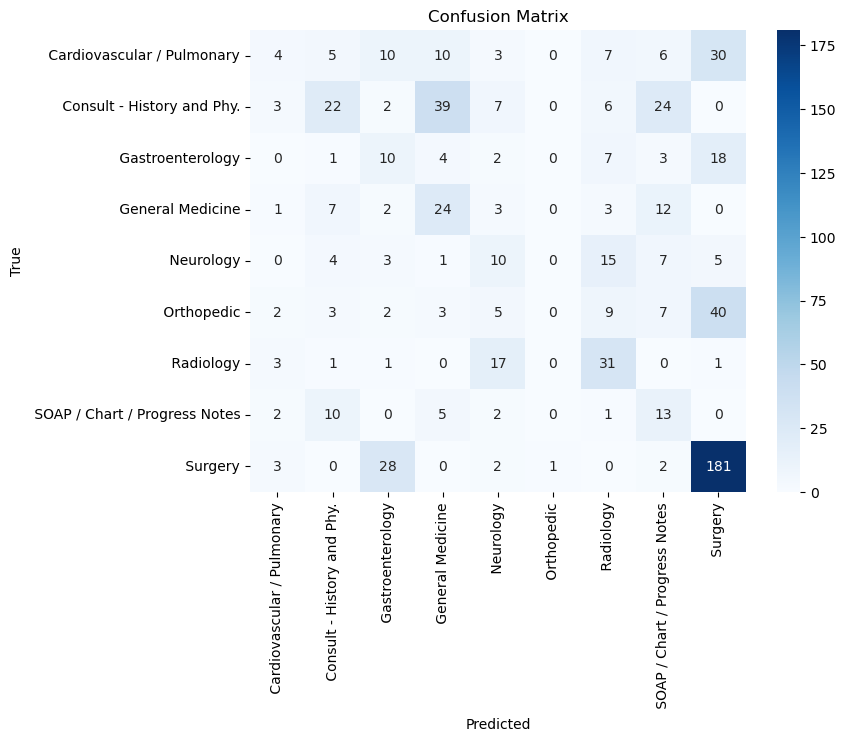

In [31]:

cf = confusion_matrix(
    all_truth,
    all_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_truth,
        all_predictions,
        target_names=encoder.classes_
    )
)

                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.22      0.05      0.09        75
    Consult - History and Phy.       0.42      0.21      0.28       103
              Gastroenterology       0.17      0.22      0.19        45
              General Medicine       0.28      0.46      0.35        52
                     Neurology       0.20      0.22      0.21        45
                    Orthopedic       0.00      0.00      0.00        71
                     Radiology       0.39      0.57      0.47        54
 SOAP / Chart / Progress Notes       0.18      0.39      0.24        33
                       Surgery       0.66      0.83      0.74       217

                      accuracy                           0.42       695
                     macro avg       0.28      0.33      0.28       695
                  weighted avg       0.37      0.42      0.38       695



Our model is too simple (not multi head, pretty shallow, not so much labels) for really good prediction! You can find architectures that performed well in the Kaggle website!
And again, there are better models than this, for example just looking at the presence of certain words etc.